   instant    dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  2011/1/1       1   0     1        0        6           0   
1        2  2011/1/2       1   0     1        0        0           0   
2        3  2011/1/3       1   0     1        0        1           1   
3        4  2011/1/4       1   0     1        0        2           1   
4        5  2011/1/5       1   0     1        0        3           1   

   weathersit      temp     atemp       hum  windspeed  casual  registered  
0           2  0.344167  0.363625  0.805833   0.160446     331         654  
1           2  0.363478  0.353739  0.696087   0.248539     131         670  
2           1  0.196364  0.189405  0.437273   0.248309     120        1229  
3           1  0.200000  0.212122  0.590435   0.160296     108        1454  
4           1  0.226957  0.229270  0.436957   0.186900      82        1518  


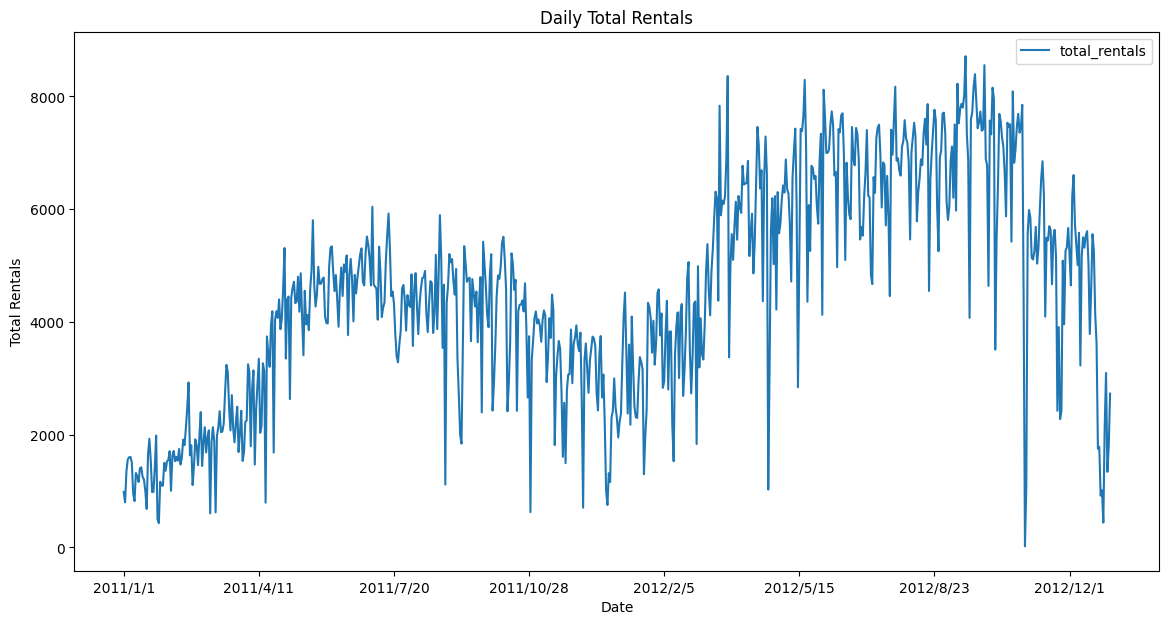

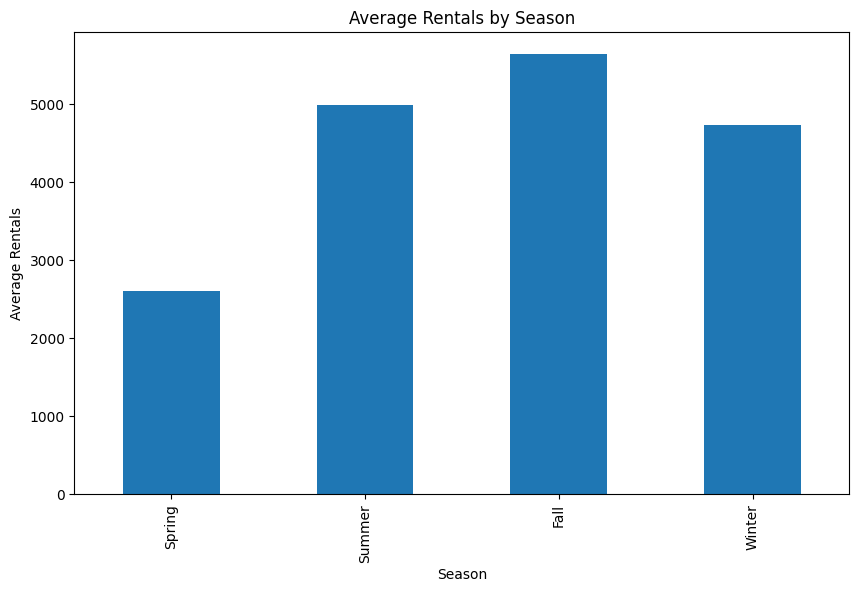

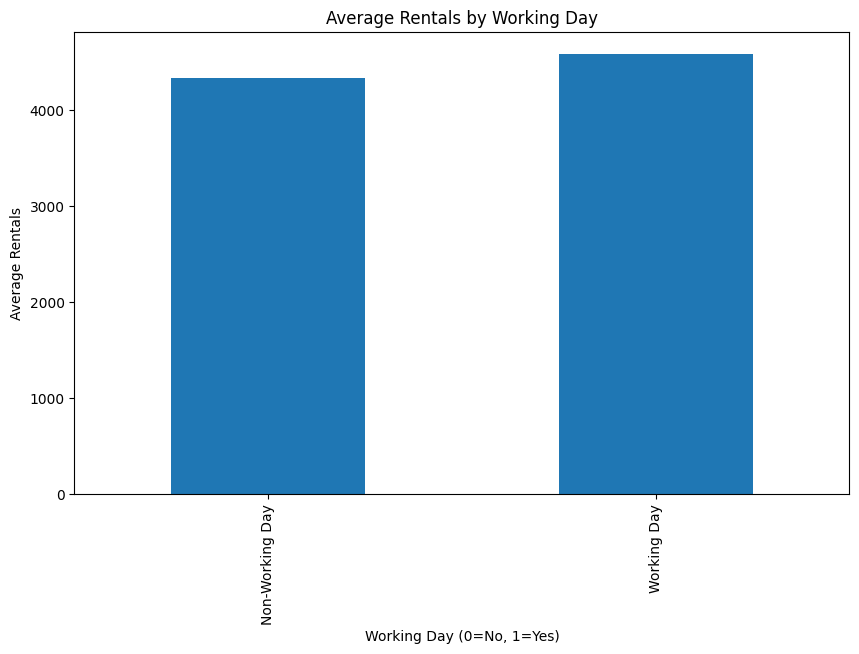

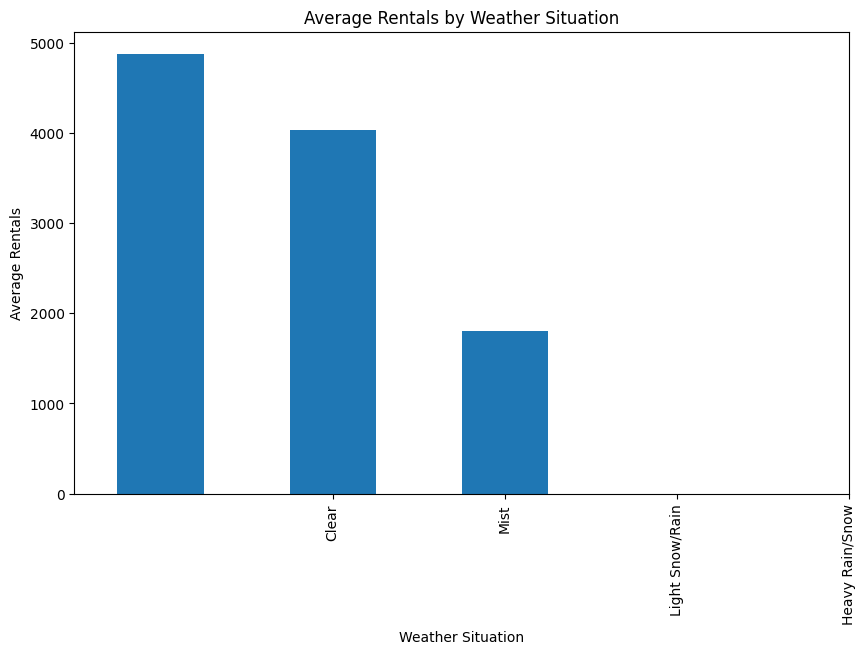

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 加载数据
data = pd.read_csv('28.bike_day.csv')

# 数据预览
print(data.head())

# 1. 每日租赁总数
data['total_rentals'] = data['casual'] + data['registered']
daily_rentals = data[['dteday', 'total_rentals']]
daily_rentals.set_index('dteday', inplace=True)
daily_rentals.plot(figsize=(14, 7), title='Daily Total Rentals')
plt.xlabel('Date')
plt.ylabel('Total Rentals')
plt.show()

# 2. 季节性趋势
seasonal_rentals = data.groupby('season')['total_rentals'].mean()
seasonal_rentals.plot(kind='bar', figsize=(10, 6), title='Average Rentals by Season')
plt.xlabel('Season')
plt.ylabel('Average Rentals')
plt.xticks(ticks=[0, 1, 2, 3], labels=['Spring', 'Summer', 'Fall', 'Winter'])
plt.show()

# 3. 工作日与非工作日的差异
workingday_rentals = data.groupby('workingday')['total_rentals'].mean()
workingday_rentals.plot(kind='bar', figsize=(10, 6), title='Average Rentals by Working Day')
plt.xlabel('Working Day (0=No, 1=Yes)')
plt.ylabel('Average Rentals')
plt.xticks(ticks=[0, 1], labels=['Non-Working Day', 'Working Day'])
plt.show()

# 4. 天气情况对租赁的影响
weather_rentals = data.groupby('weathersit')['total_rentals'].mean()
weather_rentals.plot(kind='bar', figsize=(10, 6), title='Average Rentals by Weather Situation')
plt.xlabel('Weather Situation')
plt.ylabel('Average Rentals')
plt.xticks(ticks=[1, 2, 3, 4], labels=['Clear', 'Mist', 'Light Snow/Rain', 'Heavy Rain/Snow'])
plt.show()